In [56]:
from langgraph.graph import StateGraph
from typing import TypedDict

In [57]:
# our class schema
class AgentState(TypedDict):
  length:int
  width:int
  operation:str
  area:int
  perimeter:int

In [58]:
# Node--> Function that performs an action
def get_area(state: AgentState)-> AgentState:
  """Gets the area"""
  state['area']=state['length'] * state['width']

  return state

# Perimeter node
def get_perimeter(state: AgentState)-> AgentState:
  """Gets Perimeter"""
  state['perimeter']=2*(state['length']+state['width'])

  return state

# now our Router---> decides what function to run
def decide_next_node(state: AgentState)-> str:
  """Decide the next node to run"""
  if state['operation']=="a":
    return "area_operation"
  elif state['operation']=="p":
    return "perimeter_operation"


In [59]:
# create grapph
graph=StateGraph(AgentState)

# Add our nodes
graph.add_node("area", get_area)
graph.add_node("perimeter", get_perimeter)
graph.add_node('router', lambda state:state) # pass through function. The initial state passes here

# Add edges--> decides the next node to be executed
graph.set_entry_point('router')
# our conditional edge--> selects the node to run
graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        "area_operation":"area",
        "perimeter_operation":"perimeter"
    }
)
# Only one node will be run by our router. Connect both to the END
graph.set_finish_point("area")
graph.set_finish_point("perimeter")

# compile---> make our graph an executable
app=graph.compile()

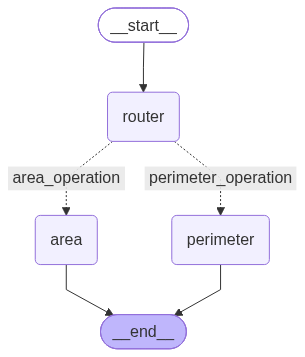

In [60]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [61]:
# try our app
app.invoke({"length":15, "width":6, "operation":"a"})

{'length': 15, 'width': 6, 'operation': 'a', 'area': 90}

In [65]:
# try perimeter
app.invoke({"length":15, "width":6, "operation":"p"})

{'length': 15, 'width': 6, 'operation': 'p', 'perimeter': 42}

In [64]:
for event in app.stream({
    "length":15,
    "width":6,
    "operation":"p"
}):
  print(event)

{'router': {'length': 15, 'width': 6, 'operation': 'p'}}
{'perimeter': {'length': 15, 'width': 6, 'operation': 'p', 'perimeter': 42}}
